In [ ]:
import pandas as pd

In [ ]:
# csv 파일 업로드
from google.colab import files

uploaded = files.upload()

Saving 202108_202607_주민등록인구및세대현황_월간_☆.csv to 202108_202607_주민등록인구및세대현황_월간_☆.csv


In [ ]:
# csv 불러오기

filename = list(uploaded.keys())[0]

df = pd.read_csv(
    filename,
    encoding='cp949'
)

print(df.shape)

(17, 361)


In [ ]:
# 확인

df.head()
df.columns.tolist()[:20]

['행정구역',
 '2021년08월_거주자 인구수',
 '2021년08월_세대수',
 '2021년08월_세대당 인구',
 '2021년08월_남자 인구수',
 '2021년08월_여자 인구수',
 '2021년08월_남여 비율',
 '2021년09월_거주자 인구수',
 '2021년09월_세대수',
 '2021년09월_세대당 인구',
 '2021년09월_남자 인구수',
 '2021년09월_여자 인구수',
 '2021년09월_남여 비율',
 '2021년10월_거주자 인구수',
 '2021년10월_세대수',
 '2021년10월_세대당 인구',
 '2021년10월_남자 인구수',
 '2021년10월_여자 인구수',
 '2021년10월_남여 비율',
 '2021년11월_거주자 인구수']

In [ ]:
# 2023~2026.06 데이터 뽑기

months = pd.date_range(
    start='2023-01-01',
    end='2026-06-01',
    freq='MS'
)

month_names = [
    f'{date.year}년{date.month:02d}월'
    for date in months
]

print(month_names)
print('개월 수:', len(month_names))

['2023년01월', '2023년02월', '2023년03월', '2023년04월', '2023년05월', '2023년06월', '2023년07월', '2023년08월', '2023년09월', '2023년10월', '2023년11월', '2023년12월', '2024년01월', '2024년02월', '2024년03월', '2024년04월', '2024년05월', '2024년06월', '2024년07월', '2024년08월', '2024년09월', '2024년10월', '2024년11월', '2024년12월', '2025년01월', '2025년02월', '2025년03월', '2025년04월', '2025년05월', '2025년06월', '2025년07월', '2025년08월', '2025년09월', '2025년10월', '2025년11월', '2025년12월', '2026년01월', '2026년02월', '2026년03월', '2026년04월', '2026년05월', '2026년06월']
개월 수: 42


In [ ]:
# 부산광역시 전체 행 제거

df = df[
    df['행정구역'].str.contains('구|군', regex=True)
].copy()

In [ ]:
# 확인

print(df['행정구역'])
print('행정구 수:', len(df))

1       부산광역시 중구 (2611000000)
2       부산광역시 서구 (2614000000)
3       부산광역시 동구 (2617000000)
4      부산광역시 영도구 (2620000000)
5     부산광역시 부산진구 (2623000000)
6      부산광역시 동래구 (2626000000)
7       부산광역시 남구 (2629000000)
8       부산광역시 북구 (2632000000)
9     부산광역시 해운대구 (2635000000)
10     부산광역시 사하구 (2638000000)
11     부산광역시 금정구 (2641000000)
12     부산광역시 강서구 (2644000000)
13     부산광역시 연제구 (2647000000)
14     부산광역시 수영구 (2650000000)
15     부산광역시 사상구 (2653000000)
16     부산광역시 기장군 (2671000000)
Name: 행정구역, dtype: object
행정구 수: 16


In [ ]:
# 행정구 이름 단순화 (부산광역시 중구 -> 중구)
df['행정구'] = (
    df['행정구역']
    .str.replace('부산광역시 ', '', regex=False)
    .str.replace(r'\s*\(\d+\)', '', regex=True)
    .str.strip()
)

In [ ]:
print(df['행정구'].tolist())

['중구', '서구', '동구', '영도구', '부산진구', '동래구', '남구', '북구', '해운대구', '사하구', '금정구', '강서구', '연제구', '수영구', '사상구', '기장군']


In [ ]:
# 행정구역 컬럼 제거
df = df.drop(columns=['행정구역'])

In [ ]:
# 총 인구수

result_list = []

for month in month_names:

    temp = pd.DataFrame()

    # 행정구
    temp['행정구'] = df['행정구']

    # 연월
    temp['연월'] = month

    # 남자 인구수
    male = (
        df[f'{month}_남자 인구수']
        .astype(str)
        .str.replace(',', '', regex=False)
        .astype(int)
    )

    # 여자 인구수
    female = (
        df[f'{month}_여자 인구수']
        .astype(str)
        .str.replace(',', '', regex=False)
        .astype(int)
    )

    # 남자 + 여자 = 총 인구수
    temp['총 인구수'] = male + female

    result_list.append(temp)

In [54]:
# 월별 데이터를 하나로 합치기
result = pd.concat(
    result_list,
    ignore_index=True
)

In [56]:
# 확인

result.head()

,행정구,연월,총 인구수
0,중구,2023년01월,39333
1,서구,2023년01월,104509
2,동구,2023년01월,85794
3,영도구,2023년01월,107401
4,부산진구,2023년01월,354486


In [59]:
#연월 단순화

# 연월을 202301 형태의 문자열로 변경
result['연월'] = (
    result['연월']
    .astype(str)
    .str.replace('년', '', regex=False)
    .str.replace('월', '', regex=False)
)

print(result.head())
print(result.dtypes)

    행정구      연월   총 인구수
0    중구  202301   39333
1    서구  202301  104509
2    동구  202301   85794
3   영도구  202301  107401
4  부산진구  202301  354486
행정구      object
연월       object
총 인구수     int64
dtype: object


In [60]:
# 최종 확인
print(result.shape)
print(
    result[['행정구', '연월']]
    .duplicated()
    .sum()
)
print(result.isnull().sum())

(672, 3)
0
행정구      0
연월       0
총 인구수    0
dtype: int64


In [ ]:
result[
    (result['행정구'] == '중구') &
    (result['연월'] == '2023-01')
]

,행정구,연월,총 인구수


In [61]:
output_filename = '부산시_행정구별_월별_총인구_202301_202606.csv'

result.to_csv(
    output_filename,
    index=False,
    encoding='utf-8-sig'
)

print('저장 완료:', output_filename)

files.download(output_filename)

저장 완료: 부산시_행정구별_월별_총인구_202301_202606.csv


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
!apt-get -qq install fonts-nanum

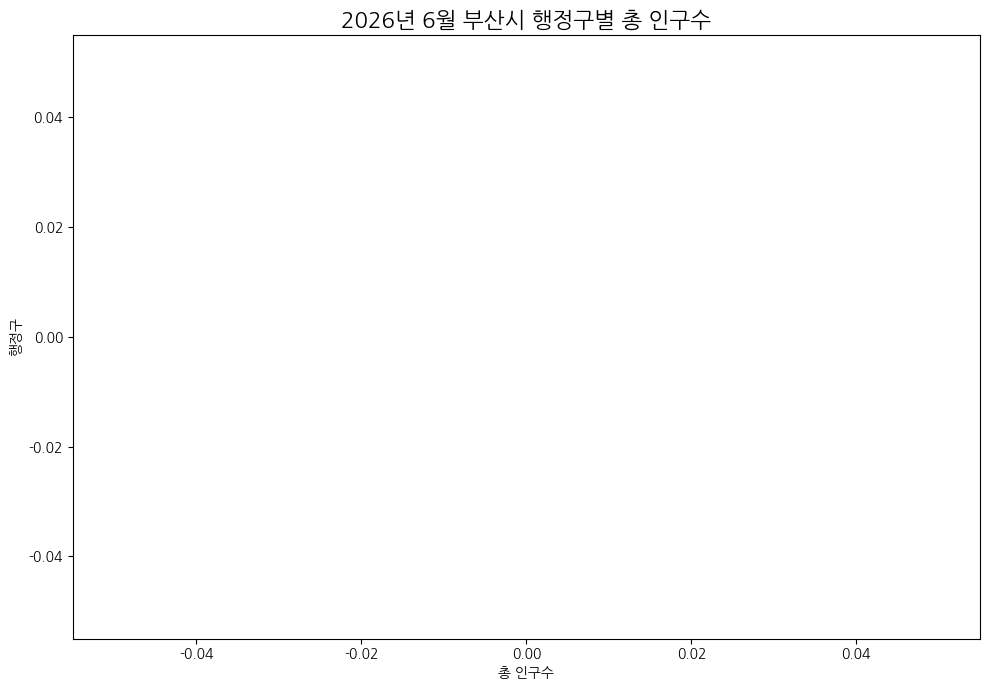

In [53]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

# 한글 폰트 직접 지정
font_path = '/usr/share/fonts/truetype/nanum/NanumGothic.ttf'

font_prop = fm.FontProperties(fname=font_path)

# CSV 불러오기
df = pd.read_csv(
    '부산시_행정구별_월별_총인구_202301_202606.csv',
    encoding='utf-8-sig'
)

# 연월의 작은따옴표 제거
df['연월'] = (
    df['연월']
    .astype(str)
    .str.replace("'", "", regex=False)
)

# 2026년 6월 데이터
latest = df[df['연월'] == '2026-06'].copy()

# 인구수가 작은 지역부터 정렬
latest = latest.sort_values('총 인구수')

# 그래프
plt.figure(figsize=(10, 7))

bars = plt.barh(
    latest['행정구'],
    latest['총 인구수']
)

# 실제 인구수 표시
for bar, value in zip(bars, latest['총 인구수']):
    plt.text(
        bar.get_width(),
        bar.get_y() + bar.get_height() / 2,
        f'{value:,}',
        va='center',
        fontsize=9,
        fontproperties=font_prop
    )

# 제목과 축에 한글 폰트 직접 적용
plt.title(
    '2026년 6월 부산시 행정구별 총 인구수',
    fontproperties=font_prop,
    fontsize=16
)

plt.xlabel(
    '총 인구수',
    fontproperties=font_prop
)

plt.ylabel(
    '행정구',
    fontproperties=font_prop
)

# y축 행정구 이름에도 한글 폰트 적용
plt.xticks(fontproperties=font_prop)
plt.yticks(fontproperties=font_prop)

plt.tight_layout()
plt.show()